# TT-25 — MLP với Keras
## Chấm điểm khách hàng tiềm năng mua bảo hiểm ô tô

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, precision_recall_curve

from data import load_and_split_onehot, load_and_split_embedding, compute_class_weight_dict
from model import build_mlp_basic, build_mlp_regularized, build_mlp_embedding, get_callbacks

DATA_PATH = "../data/train.csv"
pd.set_option("display.max_columns", None)

## 1. Đọc dữ liệu & xem tổng quan

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(381109, 12)


,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  str    
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  str    
 7   Vehicle_Damage        381109 non-null  str    
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 40.5 MB


## 2. EDA (Bước 1)

Kiểm tra tỉ lệ `Response=1` theo các biến được README lưu ý là tín hiệu mạnh:
`Previously_Insured`, `Vehicle_Damage`, và nhóm tuổi.

In [4]:
print(f"Tỉ lệ Response=1 toàn bộ: {df['Response'].mean():.3f}")
df.groupby("Previously_Insured")["Response"].mean()

Tỉ lệ Response=1 toàn bộ: 0.123


Previously_Insured
0    0.225454
1    0.000905
Name: Response, dtype: float64

In [5]:
df.groupby("Vehicle_Damage")["Response"].mean()

Vehicle_Damage
No     0.005204
Yes    0.237655
Name: Response, dtype: float64

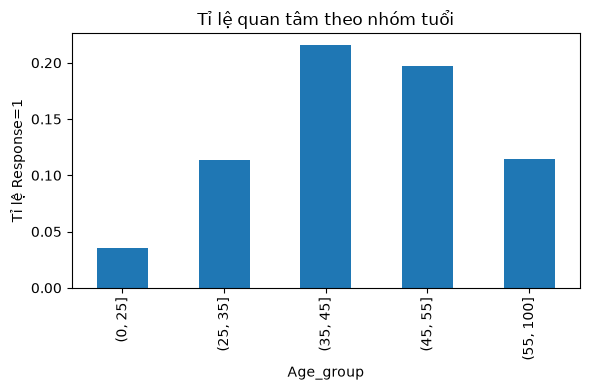

In [6]:
df["Age_group"] = pd.cut(df["Age"], bins=[0, 25, 35, 45, 55, 100])
age_rate = df.groupby("Age_group", observed=True)["Response"].mean()

age_rate.plot(kind="bar", figsize=(6, 4), title="Tỉ lệ quan tâm theo nhóm tuổi")
plt.ylabel("Tỉ lệ Response=1")
plt.tight_layout()
plt.show()

### Annual_Premium lệch phải — kiểm tra trước/sau log1p (Lưu ý #3 trong README)

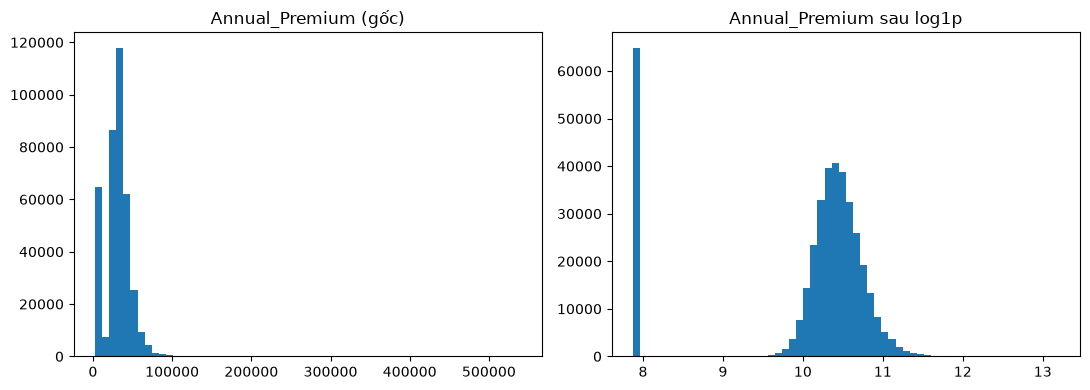

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["Annual_Premium"], bins=60)
axes[0].set_title("Annual_Premium (gốc)")

axes[1].hist(np.log1p(df["Annual_Premium"]), bins=60)
axes[1].set_title("Annual_Premium sau log1p")

plt.tight_layout()
plt.show()

### Số mức của các biến phân loại nhiều mức (Lưu ý #2 trong README)

`Region_Code` và `Policy_Sales_Channel` có nhiều mức — one-hot sẽ tạo hơn 200 cột,
đây là lý do cần thử Embedding ở bước 10.

In [8]:
print("Region_Code:", df["Region_Code"].nunique(), "mức")
print("Policy_Sales_Channel:", df["Policy_Sales_Channel"].nunique(), "mức")

Region_Code: 53 mức
Policy_Sales_Channel: 155 mức


## 3. Tiền xử lý & chia tập (Bước 2-3)

In [9]:
X_train, X_val, X_test, y_train, y_val, y_test, scaler, feature_cols = load_and_split_onehot(DATA_PATH)

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")
print(f"Tỉ lệ Response=1 (train/val/test): {y_train.mean():.3f} / {y_val.mean():.3f} / {y_test.mean():.3f}")

class_weight = compute_class_weight_dict(y_train)
class_weight

Train: (266776, 215)  Val: (57166, 215)  Test: (57167, 215)
Tỉ lệ Response=1 (train/val/test): 0.123 / 0.123 / 0.123


{0: np.float64(0.5698418055442821), 1: np.float64(4.079517998593143)}

## 4. Baseline LightGBM bắt buộc (Bước 4)

Với dữ liệu dạng bảng, cây thường thắng mạng nơ-ron — phải có baseline này để
kết luận trung thực ở cuối bài.

In [10]:
import lightgbm as lgb

lgb_clf = lgb.LGBMClassifier(n_estimators=500, class_weight="balanced", random_state=42)
lgb_clf.fit(X_train, y_train)

lgb_pred = lgb_clf.predict_proba(X_val)[:, 1]
lgb_pr_auc = average_precision_score(y_val, lgb_pred)
print(f"LightGBM — PR-AUC (val): {lgb_pr_auc:.4f}")

[LightGBM] [Info] Number of positive: 32697, number of negative: 234079
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029533 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1003
[LightGBM] [Info] Number of data points in the train set: 266776, number of used features: 147
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
LightGBM — PR-AUC (val): 0.3675


## 5. MLP cơ bản — không Dropout/BatchNorm (Bước 5)

In [11]:
mlp_basic = build_mlp_basic(X_train.shape[1])
history_basic = mlp_basic.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=100, batch_size=256, verbose=0,
    callbacks=get_callbacks("../models/mlp_basic.keras"),
)

basic_pred = mlp_basic.predict(X_val, verbose=0).ravel()
basic_pr_auc = average_precision_score(y_val, basic_pred)
print(f"MLP cơ bản — PR-AUC (val): {basic_pr_auc:.4f}")

MLP cơ bản — PR-AUC (val): 0.3684


## 6-7. MLP + Dropout/BatchNorm + learning curve (Bước 6-7)

In [12]:
mlp_reg = build_mlp_regularized(X_train.shape[1], hidden_units=(128, 64))
history_reg = mlp_reg.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=150, batch_size=256, verbose=0, class_weight=class_weight,
    callbacks=get_callbacks("../models/mlp_128_64.keras"),
)

reg_pred = mlp_reg.predict(X_val, verbose=0).ravel()
reg_pr_auc = average_precision_score(y_val, reg_pred)
print(f"MLP + Dropout/BN (128,64) — PR-AUC (val): {reg_pr_auc:.4f}  (so với cơ bản: {basic_pr_auc:.4f})")

MLP + Dropout/BN (128,64) — PR-AUC (val): 0.3674  (so với cơ bản: 0.3684)


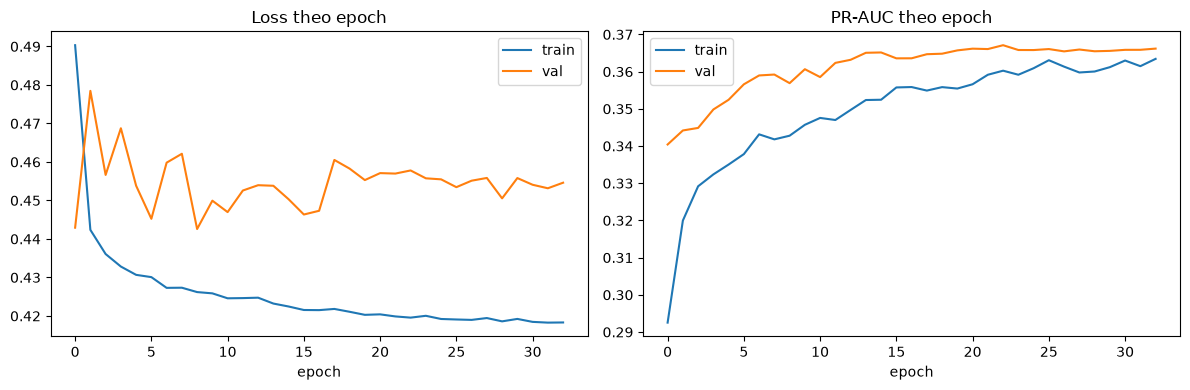

In [13]:
h = history_reg.history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(h["loss"], label="train"); axes[0].plot(h["val_loss"], label="val")
axes[0].set_title("Loss theo epoch"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(h["pr_auc"], label="train"); axes[1].plot(h["val_pr_auc"], label="val")
axes[1].set_title("PR-AUC theo epoch"); axes[1].set_xlabel("epoch"); axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/learning_curves.png", dpi=120)
plt.show()

**Đọc biểu đồ:** nếu train PR-AUC tăng liên tục mà val PR-AUC chững lại hoặc giảm →
đang overfit, Dropout/BatchNorm giúp thu hẹp khoảng cách này. Nếu cả hai đường thấp
và song song → underfit, cần model lớn hơn hoặc train lâu hơn.

## 8. So sánh 3 kiến trúc (Bước 8)

In [14]:
architectures = [(64,), (128, 64), (256, 128, 64)]
arch_results = {}

for arch in architectures:
    if arch == (128, 64):
        # đã train ở bước 6-7, dùng lại để không train trùng
        arch_results[arch] = (mlp_reg, h)
        continue
    m = build_mlp_regularized(X_train.shape[1], hidden_units=arch)
    hist = m.fit(
        X_train, y_train, validation_data=(X_val, y_val),
        epochs=150, batch_size=256, verbose=0, class_weight=class_weight,
        callbacks=get_callbacks(f"../models/mlp_{'_'.join(map(str, arch))}.keras"),
    )
    arch_results[arch] = (m, hist.history)

for arch, (m, hist) in arch_results.items():
    pr = average_precision_score(y_val, m.predict(X_val, verbose=0).ravel())
    print(f"{arch}: best val PR-AUC = {max(hist['val_pr_auc']):.4f}  (PR-AUC cuối = {pr:.4f})")

(64,): best val PR-AUC = 0.3625  (PR-AUC cuối = 0.3627)
(128, 64): best val PR-AUC = 0.3671  (PR-AUC cuối = 0.3674)
(256, 128, 64): best val PR-AUC = 0.3717  (PR-AUC cuối = 0.3719)


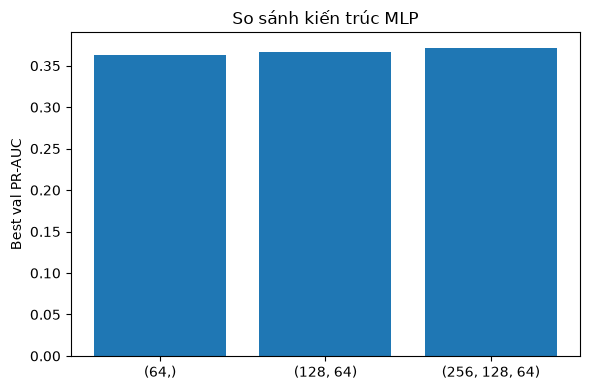

Kiến trúc tốt nhất: (256, 128, 64)


In [15]:
labels = [str(a) for a in arch_results]
values = [max(hist["val_pr_auc"]) for _, hist in arch_results.values()]

plt.figure(figsize=(6, 4))
plt.bar(labels, values)
plt.ylabel("Best val PR-AUC")
plt.title("So sánh kiến trúc MLP")
plt.tight_layout()
plt.savefig("../reports/kien_truc_comparison.png", dpi=120)
plt.show()

best_arch = max(arch_results, key=lambda a: max(arch_results[a][1]["val_pr_auc"]))
best_model = arch_results[best_arch][0]
print("Kiến trúc tốt nhất:", best_arch)

## 9. class_weight có/không, trên kiến trúc tốt nhất (Bước 9)

In [16]:
mlp_no_cw = build_mlp_regularized(X_train.shape[1], hidden_units=best_arch)
mlp_no_cw.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=150, batch_size=256, verbose=0, class_weight=None,
    callbacks=get_callbacks("../models/mlp_best_no_cw.keras"),
)

no_cw_pred = mlp_no_cw.predict(X_val, verbose=0).ravel()
no_cw_pr_auc = average_precision_score(y_val, no_cw_pred)
best_pr_auc = average_precision_score(y_val, best_model.predict(X_val, verbose=0).ravel())

print(f"Có class_weight: {best_pr_auc:.4f}")
print(f"Không class_weight: {no_cw_pr_auc:.4f}")

Có class_weight: 0.3719
Không class_weight: 0.3722


## 10. MLP + Embedding cho Region_Code, Policy_Sales_Channel (Bước 10)

In [17]:
data_emb, n_categories, n_numeric, scaler_emb, encoders = load_and_split_embedding(DATA_PATH)
X_train_e, y_train_e = data_emb["train"]
X_val_e, y_val_e = data_emb["val"]

mlp_emb = build_mlp_embedding(
    n_numeric=n_numeric,
    n_region=n_categories["region"],
    n_channel=n_categories["channel"],
)
mlp_emb.fit(
    X_train_e, y_train_e, validation_data=(X_val_e, y_val_e),
    epochs=150, batch_size=256, verbose=0,
    class_weight=compute_class_weight_dict(y_train_e),
    callbacks=get_callbacks("../models/mlp_embedding.keras"),
)

emb_pred = mlp_emb.predict(X_val_e, verbose=0).ravel()
emb_pr_auc = average_precision_score(y_val_e, emb_pred)
print(f"MLP + Embedding — PR-AUC (val): {emb_pr_auc:.4f}")
print(f"Số tham số: {mlp_emb.count_params():,}  (so với one-hot: {mlp_reg.count_params():,})")

MLP + Embedding — PR-AUC (val): 0.3748
Số tham số: 15,213  (so với one-hot: 36,737)


## 11. Precision@3000 (Bước 11)

In [18]:
def precision_at_k(y_true, y_score, k=3000):
    idx = np.argsort(y_score)[::-1][:k]
    return float(np.asarray(y_true)[idx].mean())

for name, y_true, y_pred in [
    ("LightGBM", y_val, lgb_pred),
    ("MLP cơ bản", y_val, basic_pred),
    (f"MLP + Dropout/BN {best_arch}", y_val, best_model.predict(X_val, verbose=0).ravel()),
    ("MLP + Embedding", y_val_e, emb_pred),
]:
    print(f"{name}: Precision@3000 = {precision_at_k(y_true, y_pred):.4f}")

LightGBM: Precision@3000 = 0.4210
MLP cơ bản: Precision@3000 = 0.4300
MLP + Dropout/BN (256, 128, 64): Precision@3000 = 0.4233
MLP + Embedding: Precision@3000 = 0.4240


## 12. Bảng kết luận (Bước 12)

In [19]:
results = pd.DataFrame([
    {"model": "LightGBM (baseline)", "pr_auc": lgb_pr_auc,
     "precision_at_3000": precision_at_k(y_val, lgb_pred)},
    {"model": "MLP cơ bản", "pr_auc": basic_pr_auc,
     "precision_at_3000": precision_at_k(y_val, basic_pred)},
    {"model": f"MLP + Dropout/BN {best_arch}", "pr_auc": best_pr_auc,
     "precision_at_3000": precision_at_k(y_val, best_model.predict(X_val, verbose=0).ravel())},
    {"model": f"MLP {best_arch} (không class_weight)", "pr_auc": no_cw_pr_auc,
     "precision_at_3000": precision_at_k(y_val, no_cw_pred)},
    {"model": "MLP + Embedding", "pr_auc": emb_pr_auc,
     "precision_at_3000": precision_at_k(y_val_e, emb_pred)},
]).round(4)

results

,model,pr_auc,precision_at_3000
0,LightGBM (baseline),0.3675,0.4210
1,MLP cơ bản,0.3684,0.4300
2,"MLP + Dropout/BN (256, 128, 64)",0.3719,0.4233
3,"MLP (256, 128, 64) (không class_weight)",0.3722,0.4197
4,MLP + Embedding,0.3748,0.4240


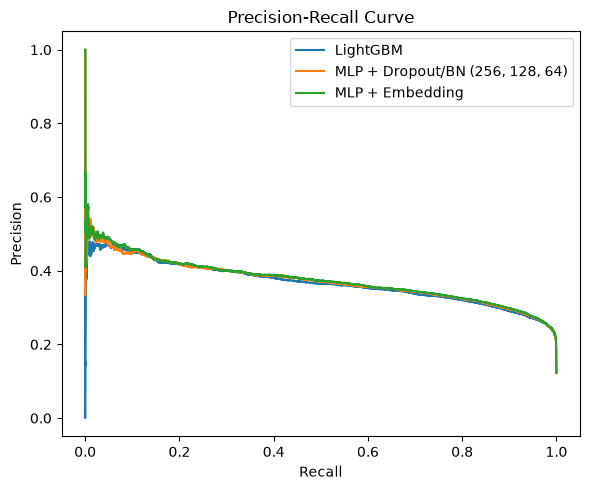

In [20]:
plt.figure(figsize=(6, 5))
for name, y_true, y_pred in [
    ("LightGBM", y_val, lgb_pred),
    (f"MLP + Dropout/BN {best_arch}", y_val, best_model.predict(X_val, verbose=0).ravel()),
    ("MLP + Embedding", y_val_e, emb_pred),
]:
    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/pr_curve.png", dpi=120)
plt.show()